## **Práctica 3 - Parte 2**

##### **Nombres:**
- Mariana Fernández Prieto
- Isabella Quinchanegua Murillo

### **Introducción**

El análisis de señales electroencefalográficas (EEG) es una herramienta fundamental en el estudio de la actividad cerebral, especialmente en aplicaciones como las interfaces cerebro-computadora (BCI). Dentro de este campo, la imaginería motora es el proceso donde un individuo imagina un movimiento sin ejecutarlo físicamente. Este tipo de estudios, ha demostrado generar patrones neuronales diferenciables, principalmente en regiones sensorimotoras del cerebro. [1,2]

En esta práctica se analizaron señales EEG provenientes de personas que imaginaron cerrar la mano izquierda y derecha. Para ello, se seleccionaron diez sujetos de la base de datos de OpenNeuro "EEG Motor Movement/Imagery Dataset", de los cuales se procesaron los registros asociados a los canales (runs) 4, 8 y 12, que contienen este tipo de tareas. Las señales fueron segmentadas en épocas y se calculó el valor RMS (Root Mean Square) como medida representativa de la energía de la señal en cada canal.

Posteriormente, se construyó una base de datos poblacional y se aplicaron pruebas estadísticas (Shapiro-Wilk, Levene y pruebas de hipótesis paramétricas o no paramétricas) con el fin de identificar canales de EEG que presentaran diferencias significativas entre ambas condiciones. Este análisis permite determinar qué regiones cerebrales contienen información relevante para diferenciar entre tareas motoras imaginadas.

In [137]:
import numpy as np
import matplotlib.pyplot as plt
import mne
import os
import pandas as pd
from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu

##### **1. Cálculo del RMS** 

1.1. Selección de 10 sujetos, separando entre grupos de estudio (mano dereza e izquierda):

En la base de datos, se eligieron 10 sujetos (1, 4, 9, 16, 25, 36, 49, 64, 81, 100). De cada uno de los sujetos elegidos, se descargaron los archivos correspondientes a las pruebas experimentales de la tarea 2 (4, 8 y 12), que es la que corresponde a la acción de imaginar abrir y cerrar la mano (derecha o izquierda). 

Los archivos descargados se organizaron en carpetas de acuerdo a su sujeto correspondiente, y se nombraron como "sub-00x" donde x es el número de sujeto del estudio. A su vez, esas carpetas se almacenaron en una carpeta nombrada "datos".

In [138]:
# Carpeta de datos
ruta = 'datos'

# Detectar carpetas de sujetos
sujetos = [s for s in os.listdir(ruta) if s.startswith('sub-')]

print(sujetos)

['sub-001', 'sub-004', 'sub-009', 'sub-016', 'sub-025', 'sub-036', 'sub-049', 'sub-064', 'sub-081', 'sub-100']


1.2. Implementación de una función que reciba una señal de múltiples canales y épocas (segmentada 
por clase) y calcule el valor RMS. 

Se crean dos matrices para separar los datos según la mano izquierda o derecha. Cada columna almacena los datos concatenados de los tres archivos de cada sujeto. Las llaves serán los canales.

El valor RMS representa la energía de la señal EEG. Es una medida cuantitativa de la intensidad a lo largo del tiempo, por lo que permite resumir cada época en un valor representativo por canal, facilitando la comparación estadística entre las condiciones de imaginería motora izquierda y derecha. [3]

In [139]:
# Función para calcular el valor RMS

def calcular_rms(datos):
    # datos: (epocas, canales, tiempo)
    rms_epocas = np.sqrt(np.mean(datos**2, axis=2))
    return np.mean(rms_epocas, axis=0)

# A. Separación de datos en mano izquierda y derecha

# Se crean las matrices para almacenar los datos de cada sujeto.
datos_matriz_izq = {}
datos_matriz_der = {}

# Ciclo for para recorrer las 10 carpetas de datos
for sujeto in sujetos:
    ruta_sujeto = os.path.join(ruta, sujeto)
    
    # Se eligen solo los archivos .set
    archivos = [f for f in os.listdir(ruta_sujeto) if f.endswith('.set')]
    
    # Lista para guardar los 3 archivos del sujeto actual
    raws_del_sujeto = []
    
    # Ruta de cada archivo
    for archivo in archivos:
        ruta_archivo = os.path.join(ruta_sujeto, archivo)
        
        # Lectura de cada archivo
        raw = mne.io.read_raw_eeglab(ruta_archivo, preload=True, verbose=False)
        #Agregar el archivo que se está leyendo a la lista
        raws_del_sujeto.append(raw)
        
    # Se unen los 3 archivos en una sola línea de tiempo continua para el sujeto
    raw_completo = mne.concatenate_raws(raws_del_sujeto)
    
    # Extracción de eventos
    events, event_id = mne.events_from_annotations(raw_completo, verbose=False)
    
    # Separación de grupos en mano izquierda y mano derecha
    canales_keys = list(event_id.keys())
    if 'TASK2T1' in canales_keys and 'TASK2T2' in canales_keys:
        clase_izq, clase_der = 'TASK2T1', 'TASK2T2'
        
    epochs = mne.Epochs(raw_completo, events, event_id=event_id, preload=True, verbose=False)
    
    epocas_izq = epochs[clase_izq].get_data()
    epocas_der = epochs[clase_der].get_data()
    
        
    # B. Cálculo del valor RMS usando la función creada anteriormente
    rms_izq = calcular_rms(epocas_izq)
    rms_der = calcular_rms(epocas_der)
    
    nombres_canales = epochs.ch_names
    
    # Agregando los datos a las matrices creadas al comienzo
    if not datos_matriz_izq:
        for ch in nombres_canales:
            datos_matriz_izq[ch] = []
            datos_matriz_der[ch] = []
            
    # Se pone el resultado de este sujeto como una nueva posición en la lista para después crear la columna
    for i, ch in enumerate(nombres_canales):
        datos_matriz_izq[ch].append(rms_izq[i])
        datos_matriz_der[ch].append(rms_der[i])

# Los diccionarios de convierten en matrices
matriz_izquierda = pd.DataFrame(datos_matriz_izq).T # Al tansponer, las filas son los canales y las columnas los sujetos

matriz_izquierda.columns = sujetos  # Se nombran las columnas con el nombre del sujeto

matriz_derecha = pd.DataFrame(datos_matriz_der).T
matriz_derecha.columns = sujetos

print("\n--- Datos mano izquierda (Canales x Sujetos) ---")
display(matriz_izquierda)

print("\n--- Datos mano derecha (Canales x Sujetos) ---")
display(matriz_derecha)


--- Datos mano izquierda (Canales x Sujetos) ---


,sub-001,sub-004,sub-009,sub-016,sub-025,sub-036,sub-049,sub-064,sub-081,sub-100
Fc5,0.000045,0.000027,0.000097,0.000025,0.000013,0.000052,0.000055,0.000022,0.000026,0.000004
Fc3,0.000047,0.000027,0.000080,0.000026,0.000014,0.000053,0.000057,0.000020,0.000025,0.000065
Fc1,0.000047,0.000032,0.000074,0.000026,0.000014,0.000053,0.000056,0.000019,0.000022,0.000064
Fcz,0.000046,0.000020,0.000073,0.000026,0.000014,0.000058,0.000058,0.000019,0.000019,0.000062
Fc2,0.000045,0.000021,0.000075,0.000026,0.000014,0.000056,0.000054,0.000018,0.000019,0.000056
...,...,...,...,...,...,...,...,...,...,...
Po8,0.000050,0.000018,0.000047,0.000018,0.000012,0.000039,0.000035,0.000013,0.000015,0.000031
O1,0.000055,0.000021,0.000047,0.000021,0.000010,0.000040,0.000040,0.000014,0.000016,0.000038
Oz,0.000051,0.000020,0.000045,0.000020,0.000010,0.000039,0.000037,0.000014,0.000015,0.000036
O2,0.000051,0.000019,0.000044,0.000019,0.000012,0.000039,0.000041,0.000014,0.000015,0.000033



--- Datos mano derecha (Canales x Sujetos) ---


,sub-001,sub-004,sub-009,sub-016,sub-025,sub-036,sub-049,sub-064,sub-081,sub-100
Fc5,0.000050,0.000025,0.000087,0.000024,0.000014,0.000060,0.000055,0.000018,0.000024,0.000004
Fc3,0.000051,0.000022,0.000069,0.000025,0.000014,0.000062,0.000052,0.000018,0.000028,0.000060
Fc1,0.000052,0.000034,0.000068,0.000024,0.000015,0.000061,0.000052,0.000018,0.000023,0.000061
Fcz,0.000054,0.000023,0.000071,0.000025,0.000014,0.000064,0.000053,0.000018,0.000022,0.000060
Fc2,0.000049,0.000023,0.000073,0.000025,0.000015,0.000060,0.000048,0.000017,0.000022,0.000054
...,...,...,...,...,...,...,...,...,...,...
Po8,0.000049,0.000019,0.000045,0.000018,0.000012,0.000043,0.000034,0.000013,0.000014,0.000025
O1,0.000052,0.000021,0.000048,0.000022,0.000010,0.000045,0.000040,0.000012,0.000015,0.000030
Oz,0.000051,0.000021,0.000046,0.000020,0.000010,0.000043,0.000040,0.000012,0.000015,0.000027
O2,0.000050,0.000020,0.000044,0.000019,0.000012,0.000042,0.000041,0.000012,0.000014,0.000024


##### **2. Construcción de la base de datos poblacional**

A partir del procesamiento de las señales EEG, se obtuvo un valor RMS representativo para cada canal. Esto permitió construir una base de datos para facilitar el análisis estadístico comparativo posterior.

In [140]:
# Transponemos las matrices (filas = sujetos, columnas = canales)
datos_izq = matriz_izquierda.T
datos_der = matriz_derecha.T

# Se crea una columna para diferenciar a que condición pertenecen los datps
datos_izq['Condicion'] = 'Izquierda'
datos_der['Condicion'] = 'Derecha'

# Se juntan las tablas
datos_final = pd.concat([datos_izq, datos_der])

# Índice en la columna 'Sujeto'
datos_final = datos_final.reset_index().rename(columns={'index': 'Sujeto'})
# Ordenar datos de un mismo sujeto
datos_final = datos_final.sort_values(by=['Sujeto', 'Condicion'], ascending=[True, False])
datos_final = datos_final.set_index(['Sujeto', 'Condicion'])

print("\n--- Base de datos poblacional: ---")
display(datos_final)


--- Base de datos poblacional: ---


Fc5       Fc3       Fc1       Fcz       Fc2       Fc4  \
Sujeto  Condicion                                                               
sub-001 Izquierda  0.000045  0.000047  0.000047  0.000046  0.000045  0.000040   
        Derecha    0.000050  0.000051  0.000052  0.000054  0.000049  0.000042   
sub-004 Izquierda  0.000027  0.000027  0.000032  0.000020  0.000021  0.000018   
        Derecha    0.000025  0.000022  0.000034  0.000023  0.000023  0.000026   
sub-009 Izquierda  0.000097  0.000080  0.000074  0.000073  0.000075  0.000082   
        Derecha    0.000087  0.000069  0.000068  0.000071  0.000073  0.000086   
sub-016 Izquierda  0.000025  0.000026  0.000026  0.000026  0.000026  0.000025   
        Derecha    0.000024  0.000025  0.000024  0.000025  0.000025  0.000025   
sub-025 Izquierda  0.000013  0.000014  0.000014  0.000014  0.000014  0.000013   
        Derecha    0.000014  0.000014  0.000015  0.000014  0.000015  0.000015   
sub-036 Izquierda  0.000052  0.000053  0.000053  0.000058  0.000056  0.000054   
        Derecha    0.000060  0.000062  0.000061  0.000064  0.000060  0.000055   
sub-049 Izquierda  0.000055  0.000057  0.000056  0.000058  0.000054  0.000054   
        Derecha    0.000055  0.000052  0.000052  0.000053  0.000048  0.000049   
sub-064 Izquierda  0.000022  0.000020  0.000019  0.000019  0.000018  0.000019   
        Derecha    0.000018  0.000018  0.000018  0.000018  0.000017  0.000017   
sub-081 Izquierda  0.000026  0.000025  0.000022  0.000019  0.000019  0.000019   
        Derecha    0.000024  0.000028  0.000023  0.000022  0.000022  0.000026   
sub-100 Izquierda  0.000004  0.000065  0.000064  0.000062  0.000056  0.000061   
        Derecha    0.000004  0.000060  0.000061  0.000060  0.000054  0.000061   

                        Fc6        C5        C3        C1  ...        P8  \
Sujeto  Condicion                                          ...             
sub-001 Izquierda  0.000033  0.000047  0.000049  0.000050  ...  0.000039   
        Derecha    0.000035  0.000046  0.000048  0.000049  ...  0.000040   
sub-004 Izquierda  0.000018  0.000024  0.000023  0.000023  ...  0.000016   
        Derecha    0.000025  0.000021  0.000021  0.000024  ...  0.000018   
sub-009 Izquierda  0.000139  0.000077  0.000068  0.000066  ...  0.000045   
        Derecha    0.000133  0.000070  0.000061  0.000062  ...  0.000043   
sub-016 Izquierda  0.000021  0.000023  0.000025  0.000026  ...  0.000018   
        Derecha    0.000021  0.000022  0.000023  0.000023  ...  0.000019   
sub-025 Izquierda  0.000013  0.000011  0.000013  0.000013  ...  0.000008   
        Derecha    0.000013  0.000011  0.000013  0.000013  ...  0.000009   
sub-036 Izquierda  0.000049  0.000046  0.000050  0.000052  ...  0.000033   
        Derecha    0.000047  0.000053  0.000057  0.000059  ...  0.000035   
sub-049 Izquierda  0.000056  0.000052  0.000055  0.000056  ...  0.000034   
        Derecha    0.000055  0.000051  0.000053  0.000054  ...  0.000033   
sub-064 Izquierda  0.000019  0.000017  0.000017  0.000018  ...  0.000011   
        Derecha    0.000016  0.000016  0.000016  0.000017  ...  0.000010   
sub-081 Izquierda  0.000018  0.000020  0.000020  0.000019  ...  0.000012   
        Derecha    0.000028  0.000019  0.000019  0.000020  ...  0.000013   
sub-100 Izquierda  0.000046  0.000059  0.000059  0.000058  ...  0.000039   
        Derecha    0.000052  0.000050  0.000053  0.000053  ...  0.000035   

                        Po7       Po3       Poz       Po4       Po8        O1  \
Sujeto  Condicion                                                               
sub-001 Izquierda  0.000054  0.000055  0.000055  0.000050  0.000050  0.000055   
        Derecha    0.000050  0.000051  0.000051  0.000048  0.000049  0.000052   
sub-004 Izquierda  0.000021  0.000021  0.000023  0.000019  0.000018  0.000021   
        Derecha    0.000020  0.000022  0.000023  0.000020  0.000019  0.000021   
sub-009 Izquierda  0.000049  0.000050  0.000050  0.000047  0.000047  0.000047   
 

##### **3. Identificación de canales diferenciales mediante análisis estadístico**

 • **Prueba de Normalidad:** Prueba de Shapiro-Wilk

In [141]:
df_stats = datos_final.reset_index()

# Se extraen los nombres de los canales (sin 'Sujeto' y 'Condicion')
canales = [c for c in df_stats.columns if c not in ['Sujeto', 'Condicion']]

# Prueba de Shapiro-Wilk
resultados_shapiro = []

for canal in canales:
    data_izq = df_stats[df_stats['Condicion'] == 'Izquierda'][canal]
    data_der = df_stats[df_stats['Condicion'] == 'Derecha'][canal]
    
    # Calculamos Shapiro-Wilk para cada grupo
    stat_i, p_izq = shapiro(data_izq)
    stat_d, p_der = shapiro(data_der)
    
    # Verificamos si ambos cumplen la normalidad (p > 0.05)
    normal = "Sí" if (p_izq > 0.05 and p_der > 0.05) else "No"
    
    resultados_shapiro.append({
        'Canal': canal,
        'p-valor Izquierda': p_izq,
        'p-valor Derecha': p_der,
        'Cumple normalidad': normal
    })

df_shapiro = pd.DataFrame(resultados_shapiro)
print("--- Resultados prueba de normalidad (Shapiro-Wilk) ---")
display(df_shapiro.round(4)) # Redondeando a 4 decimales

# Contar cuántos cumplen y cuántos no en total
conteo_normalidad = df_shapiro['Cumple normalidad'].value_counts()

print("\n--- Resumen total de Normalidad ---")
print(f"Canales que cumplen normalidad: {conteo_normalidad.get('Sí', 0)}")
print(f"Canales que no cumplen normalidad: {conteo_normalidad.get('No', 0)}")

--- Resultados prueba de normalidad (Shapiro-Wilk) ---


,Canal,p-valor Izquierda,p-valor Derecha,Cumple normalidad
0,Fc5,0.1869,0.3136,Sí
1,Fc3,0.3776,0.1408,Sí
2,Fc1,0.5169,0.1837,Sí
3,Fcz,0.0993,0.0724,Sí
4,Fc2,0.1470,0.1900,Sí
...,...,...,...,...
59,Po8,0.1206,0.0987,Sí
60,O1,0.3260,0.2904,Sí
61,Oz,0.2934,0.2072,Sí
62,O2,0.1821,0.0770,Sí



--- Resumen total de Normalidad ---
Canales que cumplen normalidad: 47
Canales que no cumplen normalidad: 17


El análisis de normalidad mostró que 42 canales cumplen con el supuesto de normalidad, mientras que 22 canales no lo cumplen. Esto indica que, aunque una parte importante de los datos sigue una distribución normal, existe una parte considerable que no lo hace, por lo que es necesario combinar métodos estadísticos paramétricos y no paramétricos en el análisis posterior para obtener resultados más confiables.

Una posible causa del comportamiento no normal es la alta variabilidad característica de las señales EEG, ya que se pueden ver afectadas por ruido biológico, movimientos o diferencias entre sujetos, lo que genera distribuciones asimétricas o con valores atípicos.

 • **Prueba de Homocedasticidad:** Prueba de Levene

In [142]:
# Prueba de Levene
resultados_levene = []

for canal in canales:
    data_izq = df_stats[df_stats['Condicion'] == 'Izquierda'][canal]
    data_der = df_stats[df_stats['Condicion'] == 'Derecha'][canal]
    
    # Calculamos Levene
    stat_l, p_levene = levene(data_izq, data_der)
    
    # Verificamos si cumple homocedasticidad (p > 0.05)
    homocedasticidad = "Sí" if p_levene > 0.05 else "No"
    
    resultados_levene.append({
        'Canal': canal,
        'p-valor Levene': p_levene,
        'Cumple homocedasticidad': homocedasticidad
    })

df_levene = pd.DataFrame(resultados_levene)
print("--- Resultados prueba de homocedasticidad (Levene) ---")
display(df_levene.round(4))

# Contar cuántos cumplen y cuántos no en total
conteo_homocedasticidad = df_levene['Cumple homocedasticidad'].value_counts()

print("\n--- Resumen total de homocedasticidad ---")
print(f"Canales que cumplen homocedasticidad: {conteo_homocedasticidad.get('Sí', 0)}")
print(f"Canales que no cumplen homocedasticidad: {conteo_homocedasticidad.get('No', 0)}")

--- Resultados prueba de homocedasticidad (Levene) ---


,Canal,p-valor Levene,Cumple homocedasticidad
0,Fc5,0.9287,Sí
1,Fc3,0.9454,Sí
2,Fc1,0.9794,Sí
3,Fcz,0.9755,Sí
4,Fc2,0.8948,Sí
...,...,...,...
59,Po8,0.8504,Sí
60,O1,0.9459,Sí
61,Oz,0.9959,Sí
62,O2,0.8996,Sí



--- Resumen total de homocedasticidad ---
Canales que cumplen homocedasticidad: 64
Canales que no cumplen homocedasticidad: 0


El análisis de homocedasticidad evidenció que los 64 canales evaluados cumplen con el supuesto de igualdad de varianzas, lo que indica que la dispersión de los datos es similar entre la mano izquierda y derecha. Esto permite aplicar con mayor seguridad pruebas estadísticas paramétricas en los casos donde también se cumpla el supuesto de la prueba anterior.

Una posible causa de este comportamiento es que las condiciones experimentales generan niveles de variabilidad similares en la actividad cerebral, ya que ambas tareas activan regiones sensorimotoras de forma comparable, manteniendo una dispersión homogénea en los valores de RMS entre grupos.

 • **Prueba de Hipótesis:** Prueba t o Prueba U de Mann-Whitney

In [143]:
# Prueba de hipótesis
resultados_hipotesis = []

# Se unen los datos anteriores para determinar que prueba aplicar
for index, row in df_shapiro.iterrows():
    canal = row['Canal']
    es_normal = row['Cumple normalidad']
    es_homocedastico = df_levene[df_levene['Canal'] == canal]['Cumple homocedasticidad'].values[0]
    
    data_izq = df_stats[df_stats['Condicion'] == 'Izquierda'][canal]
    data_der = df_stats[df_stats['Condicion'] == 'Derecha'][canal]
    
    # Elección de prueba de hipótesis a aplicar
    if es_normal == "Sí" and es_homocedastico == "Sí":
        prueba_usada = "t-Student"
        stat, p_final = ttest_ind(data_izq, data_der)
    else:
        prueba_usada = "Mann-Whitney U"
        stat, p_final = mannwhitneyu(data_izq, data_der)
        
    # Se valida si la diferencia es estadísticamente significativa 
    significativo = "Sí" if p_final > 0.05 else "No"
    
    resultados_hipotesis.append({
        'Canal': canal,
        'Prueba Aplicada': prueba_usada,
        'Estadístico': stat,
        'p-valor': p_final,
        'Cumple H0': significativo
    })

df_hipotesis = pd.DataFrame(resultados_hipotesis)

print("\n--- Resultados prueba de hipótesis ---")
display(df_hipotesis.round({'Estadístico': 4, 'p-valor': 5}))

print("--- Resumen de pruebas de hipótesis ---")

# Se obtienen las pruebas que se aplicaron (t-Student, Mann-Whitney)
pruebas_usadas = df_hipotesis['Prueba Aplicada'].unique()

for prueba in pruebas_usadas:
    df_prueba = df_hipotesis[df_hipotesis['Prueba Aplicada'] == prueba]
    
    # Contar cuántos cumplen y cuántos no en total
    totales = len(df_prueba)
    significativos = len(df_prueba[df_prueba['p-valor'] < 0.05])
    no_significativos = totales - significativos
    
    # Imprimimos el texto
    print(f"\n🔹 {prueba}:")
    print(f"Canales con diferencia significativa (p < 0.05): {significativos}")
    print(f"Canales sin diferencia significativa: {no_significativos}")




--- Resultados prueba de hipótesis ---


,Canal,Prueba Aplicada,Estadístico,p-valor,Cumple H0
0,Fc5,t-Student,0.0327,0.97426,Sí
1,Fc3,t-Student,0.1354,0.89383,Sí
2,Fc1,t-Student,-0.0092,0.99277,Sí
3,Fcz,t-Student,-0.0687,0.94599,Sí
4,Fc2,t-Student,-0.0232,0.98173,Sí
...,...,...,...,...,...
59,Po8,t-Student,0.1071,0.91593,Sí
60,O1,t-Student,0.0927,0.92717,Sí
61,Oz,t-Student,0.0252,0.98014,Sí
62,O2,t-Student,0.1212,0.90485,Sí


--- Resumen de pruebas de hipótesis ---

🔹 t-Student:
Canales con diferencia significativa (p < 0.05): 0
Canales sin diferencia significativa: 47

🔹 Mann-Whitney U:
Canales con diferencia significativa (p < 0.05): 0
Canales sin diferencia significativa: 17


El análisis de pruebas de hipótesis mostró que ningún canal presentó diferencias estadísticamente significativas (p < 0.05) entre las condiciones de imaginería motora izquierda y derecha, tanto en la prueba t de Student (42 canales) como en la prueba no paramétrica de Mann-Whitney U (22 canales). Incluso, canales como el Fc5 alcanzaron valores muy cercanos a 1, indicando que las medias entre ambos grupos son prácticamente las mismas.

Esto sugiere que, bajo las condiciones y el procesamiento aplicado, no se evidencian diferencias claras en la energía de la señal (RMS) entre ambas tareas. Esto podría estar relacionado con la necesidad de aplicar técnicas de procesamiento más específicas (como filtrado) para resaltar patrones diferenciales, debido a que las señales EEG tienen fluctuaciones naturales y ruido que pueden ocultar diferencias reales entre las condiciones.

Otra razón puede ser que el número de sujetos puede ser insuficiente para detectar diferencias estadísticas significativas. Una muestra de 10 sujetos puede ser un valor pequeño, teniendo en cuenta que la base de datos alcanzaba el estudio de 109 personas.

No hubo canales con p < 0.05. Estos son los 3 canales con mayor diferencia:


,Canal,Prueba Aplicada,p-valor
0,P1,Mann-Whitney U,0.677585
1,F8,t-Student,0.699987
2,T10,Mann-Whitney U,0.733730


C:\Users\isaqm\AppData\Local\Temp\ipykernel_28568\2776128757.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["Mano Izquierda", "Mano Derecha"])


Text(1.5, 5.441199996972715e-05, 'p-valor = 0.6776')

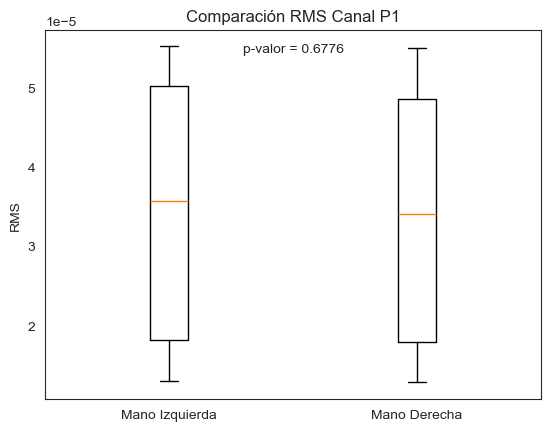

In [144]:
# Se filtran los canales que tienen p < 0.05 y se ordenan del mejor al peor
df_sig = df_hipotesis[df_hipotesis['p-valor'] < 0.05]

# Tabla de canales con diferencias significativas
if not df_sig.empty:
    print("Canales con diferencia estadística significativa (p < 0.05):")
    display(df_sig[['Canal', 'Prueba Aplicada', 'p-valor']])
    
    mejor_canal = df_sig.iloc[0]['Canal']
    mejor_pval = df_sig.iloc[0]['p-valor']
    
else:
    print("No hubo canales con p < 0.05. Estos son los 3 canales con mayor diferencia:")
    df_sig = df_hipotesis.sort_values(by='p-valor').reset_index(drop=True)
    display(df_sig[['Canal', 'Prueba Aplicada', 'p-valor']].head(3))
    
    mejor_canal = df_sig.iloc[0]['Canal']
    mejor_pval = df_sig.iloc[0]['p-valor']

# Boxplot del canal más significativo
df = datos_final.reset_index() if 'Condicion' not in datos_final.columns else datos_final

# Se extraen los datos usando la variable 'mejor_canal'
data = [df[df['Condicion'] == 'Izquierda'][mejor_canal].values, df[df['Condicion'] == 'Derecha'][mejor_canal].values]

# Gráfica del boxplot
plt.boxplot(data, labels=["Mano Izquierda", "Mano Derecha"])

# Títulos de ejes
plt.title(f"Comparación RMS Canal {mejor_canal}")
plt.ylabel("RMS")

# p-valor del canal
y_max = plt.gca().get_ylim()[1]
plt.text(1.5, y_max * 0.95, f'p-valor = {mejor_pval:.4f}', 
         ha='center', bbox=dict(facecolor='white', alpha=0.8))


Aunque no se encontraron canales con diferencias estadísticamente significativas (p < 0.05), se tabularon los tres canales que presentan los valores-p más bajos, lo que indica una mayor tendencia a la diferenciación entre las condiciones de imaginería motora.

Sin embargo, estos canales siguen teniendo valores mucho mayores a 0.05, por lo que siguen sin ser relevantes en las búsqueda de diferencias significativas. El boxplot del canal F8 muestra distribuciones muy similares del RMS entre las condiciones de mano izquierda y mano derecha, con una ligera tendencia a valores mayores y mayor dispersión en la mano izquierda. El valor-p obtenido (0.6493) es el más bajo entre todos los canales analizados. En conjunto, estos resultados sugieren que ningún canal, incluido F8, logra discriminar de manera confiable entre las dos condiciones en este análisis.

Desde el punto de vista neurofisiológico, este comportamiento es esperable, ya que la imaginería motora genera cambios sutiles en la actividad cerebral que pueden no ser capturados completamente mediante métricas globales como el RMS. Además, factores la presencia de ruido pueden disminuir la capacidad de detectar diferencias claras.

### **Conclusiones:**

1. El análisis basado en el valor RMS permitió caracterizar la energía de las señales EEG; sin embargo, no fue suficiente para identificar diferencias estadísticamente significativas entre las condiciones de imaginería motora izquierda y derecha.

2. Ningún canal demostró tendencia a tener diferencias significativas, por lo que se necesita de un procesado, estudio y análisis más robusto para hallar los resultados esperados.

3. Los resultados evidencian la necesidad de aplicar métodos más avanzados, como el filtrado o la extracción de características más diferenciadoras, para mejorar la detección de patrones asociados a la imaginería motora en aplicaciones de interfaces cerebro-computadora.

### **Referencias**

[1] Yu, H., Ba, S., Guo, Y., Guo, L., & Xu, G. (2022). Effects of Motor Imagery Tasks 
on Brain Functional Networks Based on EEG Mu/Beta Rhythm. Brain 
Sciences, 12(2), 194. https://doi.org/10.3390/brainsci12020194 

[2] Yin S, Liu Y and Ding M (2016) Amplitude of Sensorimotor Mu Rhythm Is 
Correlated with BOLD from Multiple Brain Regions: A Simultaneous EEG-fMRI 
Study. Front. Hum. Neurosci. 10:364. doi: 10.3389/fnhum.2016.00364 

[3] Bhakti. (2020, 23 abril). Peak Value, Average Value and RMS Value. Circuit Globe. https://circuitglobe.com/what-is-peak-value-average-value-and-rms-value.html

[4] Finnis, R., Mehmood, A., Holle, H., & Iqbal, J. (2025). Exploring Imagined Movement for Brain–Computer Interface Control: An fNIRS and EEG Review. Brain Sciences, 15(9), 1013. https://doi.org/10.3390/brainsci15091013